<a href="https://colab.research.google.com/github/lookmeebbear/sdb_thailand/blob/main/GeoAI_SDB_Maptapood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automatic Satellite Derived Bathymetry by Python Programming**

2108627 Geoimage Processing

Thepchai Srinoi, MEng

Department of Survey Engineering

Faculty of Engineering Chulalongkorn University

In [ ]:
# import the crucial libraries
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import folium
import folium as fo

activate google earth engine

In [ ]:
import ee
# Authenticate to the Earth Engine servers
ee.Authenticate()
# Initialize the API
ee.Initialize(project='seniorproject2022')

In [ ]:
import folium

# Map Visualization : Google Earth Engine
def add_ee_layer(self, ee_image_object, vis_params, name):
  map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
  folium.raster_layers.TileLayer(
      tiles=map_id_dict['tile_fetcher'].url_format,
      attr='Map Data &copy; <a href="https://earthengine.google.com/">Google Earth Engine</a>',
      name=name,
      overlay=True,
      control=True
  ).add_to(self)

In [ ]:
# Open the image
lat_min, lat_max, lon_min, lon_max =(12.599950, 12.700022,  101.099995, 101.200068)
AOI = ee.Geometry.Polygon(
        [[[lon_min, lat_max],
           [lon_min, lat_min],
           [lon_max, lat_min],
           [lon_max, lat_max]]])

fromdate = '2020-12-21'
todate = '2020-12-24'

image = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED').filterDate(fromdate,todate).\
          filterBounds(AOI).mosaic().divide(10000).\
          select('B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12')

# Visualization
folium.Map.add_ee_layer = add_ee_layer
c = (AOI.centroid().getInfo())['coordinates']
map_matched = folium.Map(location=[c[1], c[0]], zoom_start=13)
map_matched.add_ee_layer(image,{'min':0, 'max':0.3, 'bands':['B4','B3','B2']},'RGB_L2A')
display(map_matched.add_child(folium.LayerControl()))

In [ ]:
B8_threshold = 0.1

B8_c = (image.select('B8').lt(B8_threshold)).selfMask()

B2_lm = image.select('B2').multiply(B8_c)
B3_lm = image.select('B3').multiply(B8_c)
B4_lm = image.select('B4').multiply(B8_c)
B8_lm = image.select('B8').multiply(B8_c)

image = image.addBands(B2_lm.rename('B2_lm'))
image = image.addBands(B3_lm.rename('B3_lm'))
image = image.addBands(B4_lm.rename('B4_lm'))
image = image.addBands(B8_lm.rename('B8_lm'))

folium.Map.add_ee_layer = add_ee_layer
c = (AOI.centroid().getInfo())['coordinates']
map_matched = folium.Map(location=[c[1], c[0]], zoom_start=13)
map_matched.add_ee_layer(image,{'min':0, 'max':0.2, 'bands':['B4_lm','B3_lm','B2_lm']},'RGB_LM_L2A')
display(map_matched.add_child(folium.LayerControl()))

In [ ]:
nB2 = B2_lm.multiply(1000)
nB3 = B3_lm.multiply(1000)
logratio = (nB2.log()).divide(nB3.log())
image = image.addBands(logratio.rename('logratio'))
folium.Map.add_ee_layer = add_ee_layer
c = (AOI.centroid().getInfo())['coordinates']
map_matched = folium.Map(location=[c[1], c[0]], zoom_start=13)
map_matched.add_ee_layer(image,{'min':0, 'max':0.2, 'bands':['B4','B3','B2']},'RGB_L2A')
map_matched.add_ee_layer(image.select('logratio'),{'min':0.9, 'max':1.1},'logratio')
display(map_matched.add_child(folium.LayerControl()))

In [ ]:
imageCrop = logratio.clip(AOI)

folium.Map.add_ee_layer = add_ee_layer
c = (AOI.centroid().getInfo())['coordinates']
map_matched = folium.Map(location=[c[1], c[0]], zoom_start=13)
map_matched.add_ee_layer(image,{'min':0, 'max':0.2, 'bands':['B4','B3','B2']},'RGB_L2A')
map_matched.add_ee_layer(imageCrop, {'min':0.9, 'max':1.1},'logratio')
display(map_matched.add_child(folium.LayerControl()))

In [ ]:
task = ee.batch.Export.image.toDrive(**{
    'image': imageCrop,
    'description': 'logratio_rayonghee',
    'folder': 'GeoAI_SVCU',
    'scale': 10,
    'crs':'EPSG:32647',
    'region': AOI,
    'fileFormat': 'GeoTIFF',
    'formatOptions': {
      'cloudOptimized': 'true'
    },
})
task.start()
import time
while task.active():
  print('Polling for task (id: {}).'.format(task.id))
  time.sleep(5)

Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).
Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).
Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).
Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).
Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).
Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).
Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).
Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).
Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).
Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).
Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).
Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).
Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).
Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).
Polling for task (id: J2RB4TBOO5HYHZDHX3AF4ERT).


นำเข้าข้อมูลค่าระดับท้องน้ำ single beam echo sounding (ข้อมูลจาก คุณประจวบ เรียบร้อย Italianthai Development ภายใต้การติดต่อขอข้อมูลโดย รศ.ดร.ไพศาล สันติธรรมนนท์ Chulalongkorn University)

In [ ]:
import pandas as pd
link = 'https://raw.githubusercontent.com/lookmeebbear/OpenRS_MIST2023/main/dataset1.csv'
df = pd.read_csv(link)
df

,lon,lat,E,N,H
0,101.139933,12.657334,732420.730,1400193.420,-4.200
1,101.139887,12.657608,732415.440,1400223.750,-4.130
2,101.139831,12.657763,732409.220,1400240.810,-3.590
3,101.139614,12.658080,732385.320,1400275.730,-2.630
4,101.139713,12.657956,732396.190,1400262.090,-2.520
...,...,...,...,...,...
517,101.139591,12.658313,732382.599,1400301.441,3.824
518,101.139577,12.658302,732381.135,1400300.227,2.439
519,101.139537,12.658381,732376.656,1400308.916,3.980
520,101.139518,12.658371,732374.681,1400307.886,2.854


In [ ]:
import geopandas as gpd
from shapely.geometry import Point

# df has columns: lat, lon, class
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.E, df.N),
    crs="EPSG:32647"   # WGS84 (lat/lon)
)

In [ ]:
PATH = '/content/drive/MyDrive/GeoAI_SVCU/logratio_rayonghee.tif'

In [ ]:
import rasterio as rio

In [ ]:
myimg = rio.open( PATH )
type(myimg)

rasterio.io.DatasetReader

In [ ]:
myimg.count, myimg.width, myimg.height

(1, 1097, 1118)

In [ ]:
myimg.bounds

BoundingBox(left=728040.0, bottom=1393800.0, right=739010.0, top=1404980.0)

In [ ]:
myimg.read(1)

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

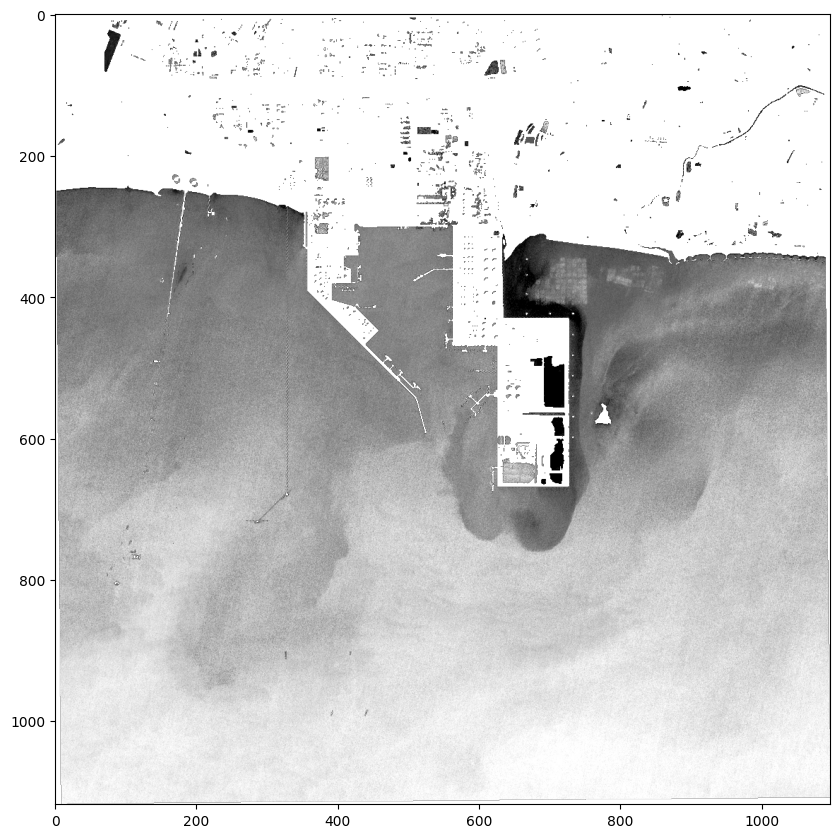

In [ ]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,1, figsize=(10,20))
plt.imshow(myimg.read(1), cmap='Greys_r', vmin=0.9, vmax=1.1)

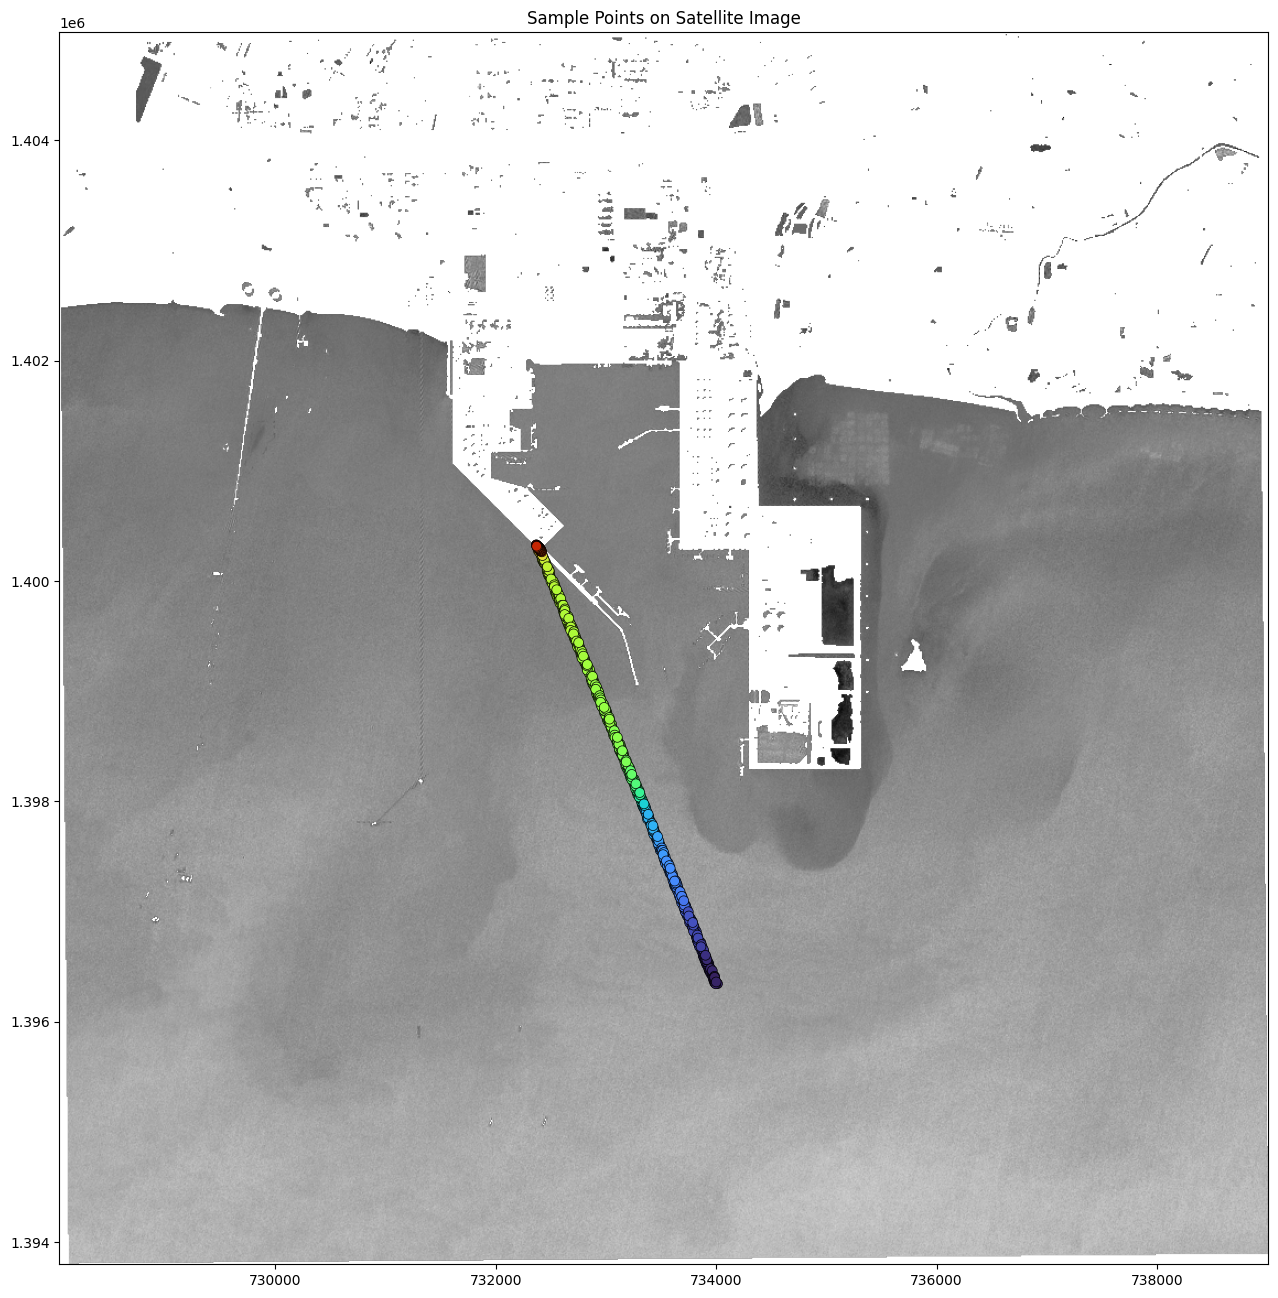

In [ ]:
import matplotlib.pyplot as plt
from rasterio.plot import show
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(16, 16))

show(myimg.read(1) , transform=myimg.transform, ax=ax , cmap='Greys_r')


gdf.plot(
    ax=ax,
    column='H',
    cmap='turbo',
    markersize=50,
    edgecolor='black',
    linewidth=0.5,
)

ax.set_title('Sample Points on Satellite Image')
plt.show()

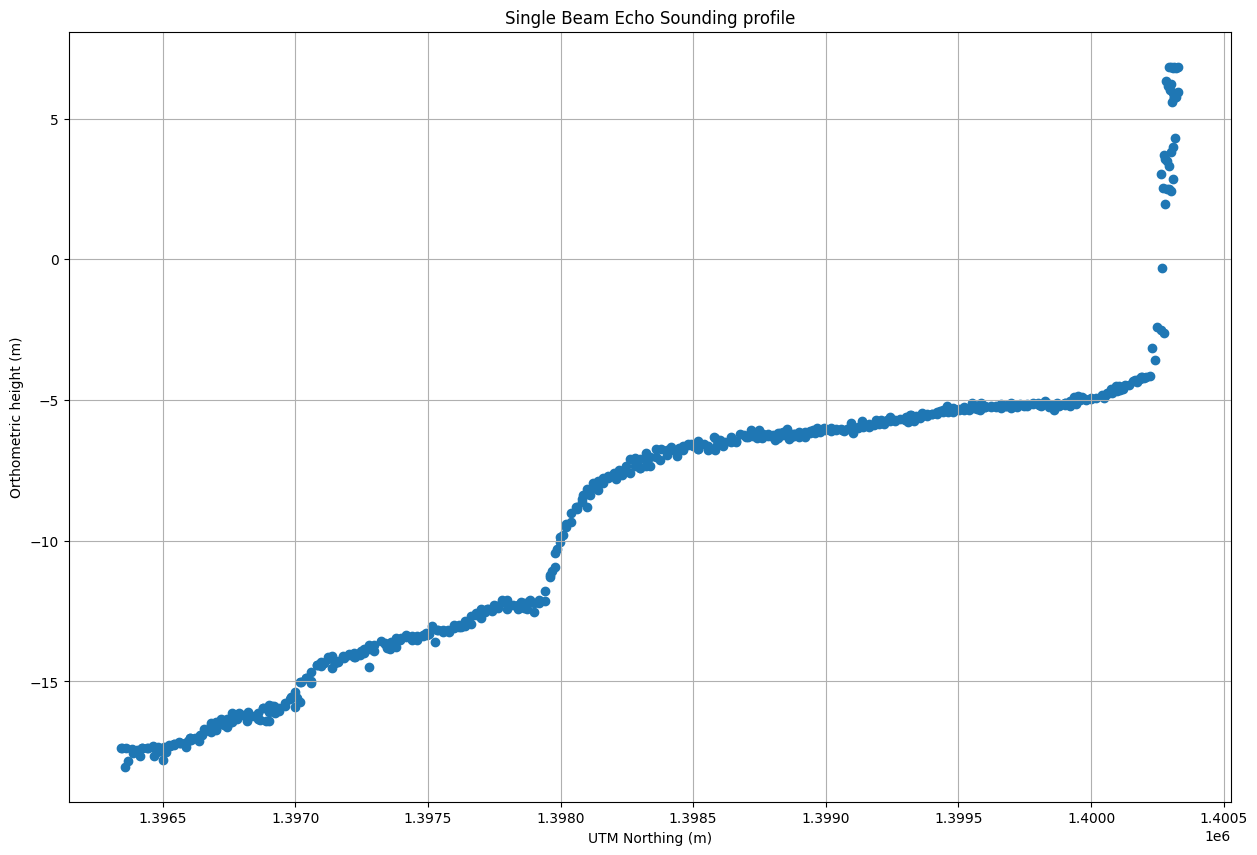

In [ ]:
plt.rcParams['figure.figsize'] = [15, 10]
def depthplot(X,Y) :
  plt.title('Single Beam Echo Sounding profile')
  plt.ylabel('Orthometric height (m)')
  plt.xlabel('UTM Northing (m)')
  plt.scatter(X,Y)
  plt.grid()
  plt.show()
depthplot(gdf.N, gdf.H)

In [ ]:
gdf['value'] = [ x for x in myimg.sample( [(x,y) for x,y in zip(gdf.E, gdf.N)] ) ]
gdf

,lon,lat,E,N,H,geometry,value
0,101.139933,12.657334,732420.730,1400193.420,-4.200,POINT (732420.73 1400193.42),[0.9850293047267346]
1,101.139887,12.657608,732415.440,1400223.750,-4.130,POINT (732415.44 1400223.75),[0.982807139307575]
2,101.139831,12.657763,732409.220,1400240.810,-3.590,POINT (732409.22 1400240.81),[0.984303410672561]
3,101.139614,12.658080,732385.320,1400275.730,-2.630,POINT (732385.32 1400275.73),[0.9930805698576813]
4,101.139713,12.657956,732396.190,1400262.090,-2.520,POINT (732396.19 1400262.09),[0.994029445079953]
...,...,...,...,...,...,...,...
517,101.139591,12.658313,732382.599,1400301.441,3.824,POINT (732382.599 1400301.441),[nan]
518,101.139577,12.658302,732381.135,1400300.227,2.439,POINT (732381.135 1400300.227),[nan]
519,101.139537,12.658381,732376.656,1400308.916,3.980,POINT (732376.656 1400308.916),[nan]
520,101.139518,12.658371,732374.681,1400307.886,2.854,POINT (732374.681 1400307.886),[nan]


In [ ]:
gdf[ 'logratio' ] = [x[0] for x in list( gdf.value )]
gdf

,lon,lat,E,N,H,geometry,value,logratio
0,101.139933,12.657334,732420.730,1400193.420,-4.200,POINT (732420.73 1400193.42),[0.9850293047267346],0.985029
1,101.139887,12.657608,732415.440,1400223.750,-4.130,POINT (732415.44 1400223.75),[0.982807139307575],0.982807
2,101.139831,12.657763,732409.220,1400240.810,-3.590,POINT (732409.22 1400240.81),[0.984303410672561],0.984303
3,101.139614,12.658080,732385.320,1400275.730,-2.630,POINT (732385.32 1400275.73),[0.9930805698576813],0.993081
4,101.139713,12.657956,732396.190,1400262.090,-2.520,POINT (732396.19 1400262.09),[0.994029445079953],0.994029
...,...,...,...,...,...,...,...,...
517,101.139591,12.658313,732382.599,1400301.441,3.824,POINT (732382.599 1400301.441),[nan],NaN
518,101.139577,12.658302,732381.135,1400300.227,2.439,POINT (732381.135 1400300.227),[nan],NaN
519,101.139537,12.658381,732376.656,1400308.916,3.980,POINT (732376.656 1400308.916),[nan],NaN
520,101.139518,12.658371,732374.681,1400307.886,2.854,POINT (732374.681 1400307.886),[nan],NaN


In [ ]:
gdf = gdf.dropna()
gdf

,lon,lat,E,N,H,geometry,value,logratio
0,101.139933,12.657334,732420.73,1400193.42,-4.20,POINT (732420.73 1400193.42),[0.9850293047267346],0.985029
1,101.139887,12.657608,732415.44,1400223.75,-4.13,POINT (732415.44 1400223.75),[0.982807139307575],0.982807
2,101.139831,12.657763,732409.22,1400240.81,-3.59,POINT (732409.22 1400240.81),[0.984303410672561],0.984303
3,101.139614,12.658080,732385.32,1400275.73,-2.63,POINT (732385.32 1400275.73),[0.9930805698576813],0.993081
4,101.139713,12.657956,732396.19,1400262.09,-2.52,POINT (732396.19 1400262.09),[0.994029445079953],0.994029
...,...,...,...,...,...,...,...,...
485,101.154040,12.622839,733984.97,1396388.99,-17.55,POINT (733984.97 1396388.99),[1.047345452479498],1.047345
486,101.154042,12.622972,733984.97,1396403.70,-17.51,POINT (733984.97 1396403.7),[1.034064207458806],1.034064
487,101.154283,12.622450,734011.64,1396346.16,-17.38,POINT (734011.64 1396346.16),[1.045186082140674],1.045186
488,101.154136,12.622439,733995.75,1396344.79,-17.37,POINT (733995.75 1396344.79),[1.0568951746945174],1.056895


In [ ]:
df_play = gdf.copy()

In [ ]:
x = df_play[ ['E','N', 'logratio']  ]
y = df_play[ 'H' ]

In [ ]:
x

,E,N,logratio
0,732420.73,1400193.42,0.985029
1,732415.44,1400223.75,0.982807
2,732409.22,1400240.81,0.984303
3,732385.32,1400275.73,0.993081
4,732396.19,1400262.09,0.994029
...,...,...,...
485,733984.97,1396388.99,1.047345
486,733984.97,1396403.70,1.034064
487,734011.64,1396346.16,1.045186
488,733995.75,1396344.79,1.056895


In [ ]:
y

,H
0,-4.20
1,-4.13
2,-3.59
3,-2.63
4,-2.52
...,...
485,-17.55
486,-17.51
487,-17.38
488,-17.37


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.5, random_state=42)

In [ ]:
X_train = X_train.drop(columns=['E','N'])

In [ ]:
X_train

,logratio
194,1.022310
89,0.989705
146,0.983592
163,1.020315
255,1.015683
...,...
106,0.989987
270,1.019730
348,1.034728
435,1.036890


In [ ]:
y_train

,H
194,-6.30
89,-5.22
146,-6.00
163,-6.40
255,-7.50
...,...
106,-5.73
270,-7.87
348,-13.46
435,-16.42


/tmp/ipykernel_3314/3716182046.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Stumpf', model_sdb_st.score(X_train,y_train), model_sdb_st.intercept_, float(model_sdb_st.coef_) )


Stumpf 0.6924297855704492 143.62170099519935 -150.25413105809446


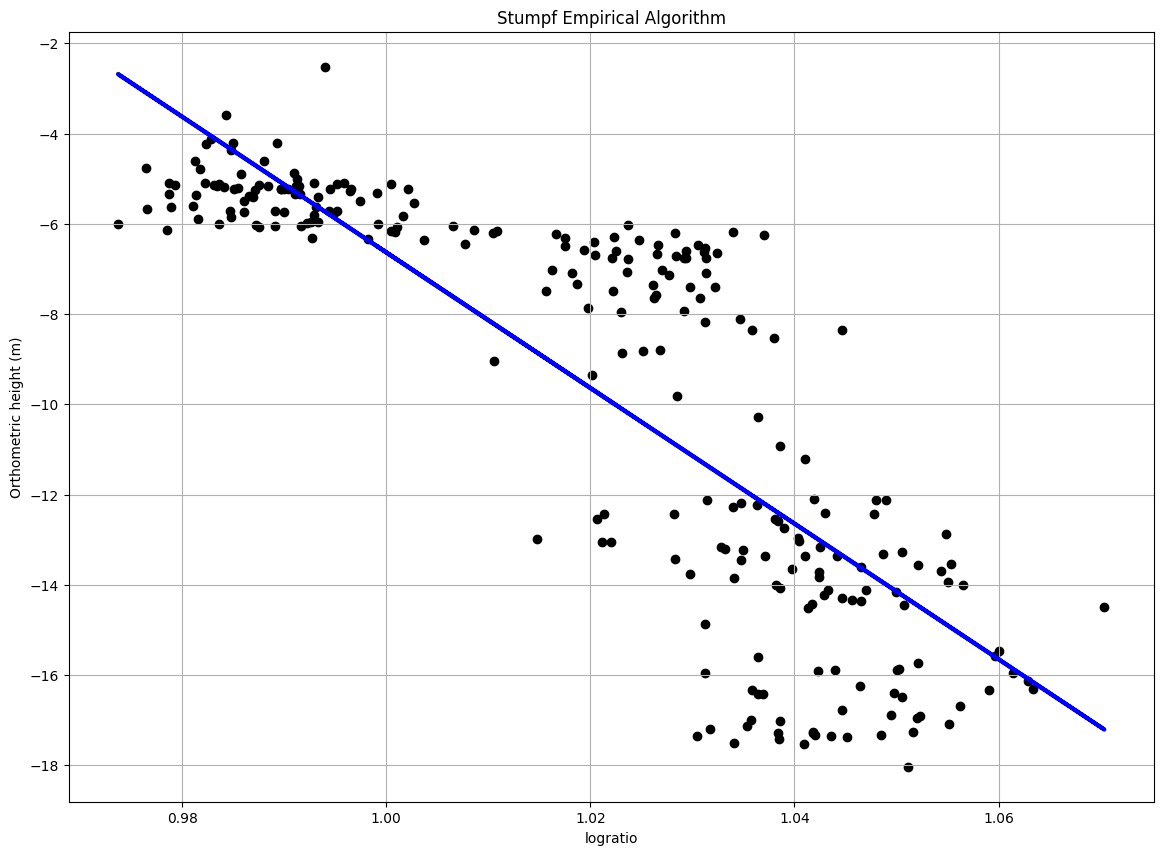

In [ ]:
plt.rcParams['figure.figsize'] = [14, 10]

lr = LinearRegression()
model_sdb_st = lr.fit(X_train,y_train)

print('Stumpf', model_sdb_st.score(X_train,y_train), model_sdb_st.intercept_, float(model_sdb_st.coef_) )

plt.scatter(X_train, y_train, color = 'black')
plt.plot(X_train, model_sdb_st.predict(X_train), color = 'blue', linewidth = 3)

plt.title('Stumpf Empirical Algorithm')

plt.ylabel('Orthometric height (m)')
plt.xlabel('logratio')
plt.grid()

plt.show()

In [ ]:
slope = float(model_sdb_st.coef_)
intercept = model_sdb_st.intercept_
print(slope,intercept)

-150.25413105809446 143.62170099519935


/tmp/ipykernel_3314/1773304515.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  slope = float(model_sdb_st.coef_)


In [ ]:
SDB = slope*myimg.read(1) + intercept

In [ ]:
new_image = '/content/mysdb.tif'

with rio.open(PATH,'r') as src:
    profile = src.profile
    with rio.open(new_image, 'w', **profile) as dst:
        dst.write(SDB.astype(rio.float32), 1)


In [ ]:
# Open Image
out = rio.open(new_image)

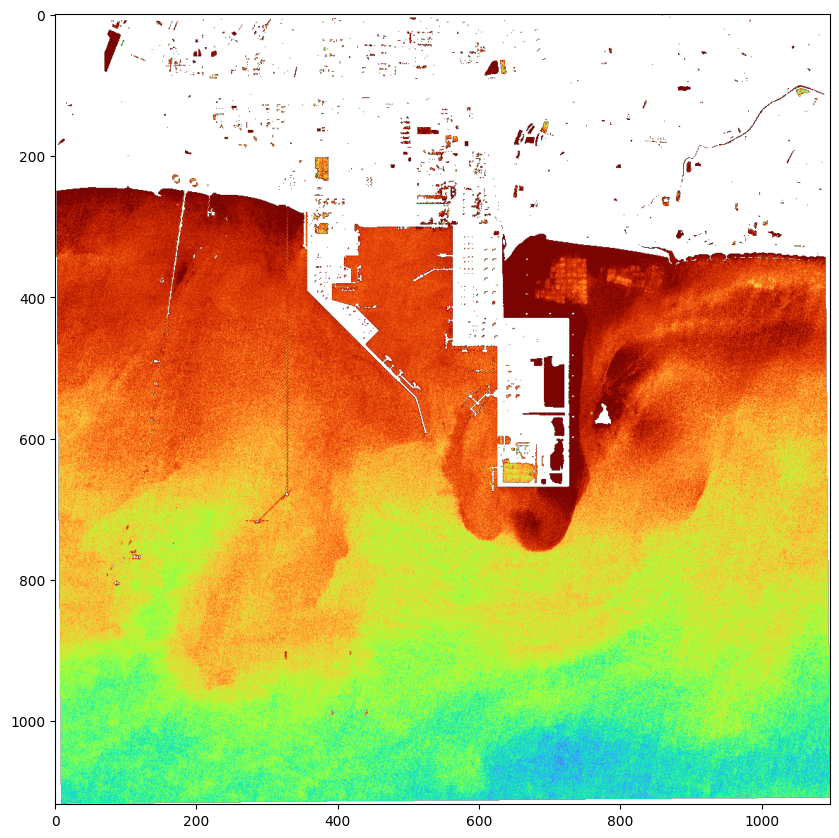

In [ ]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,1, figsize=(10,20))
plt.imshow(out.read(1), cmap='turbo', vmin=-30, vmax=0)

In [ ]:
# Sample Predicted Class
X_test['pred'] = [ x[0] for x in out.sample( [(x,y) for x,y in zip(X_test.E, X_test.N)] ) ]
X_test

,E,N,logratio,pred
452,733872.20,1396659.95,1.053565,-14.680789
84,732692.30,1399580.28,0.983872,-4.209198
434,733854.17,1396702.16,1.068048,-16.856869
473,733974.35,1396384.80,1.054760,-14.860362
428,733827.38,1396741.52,1.052118,-14.463435
...,...,...,...,...
367,733627.98,1397225.56,1.046448,-13.611408
198,733028.97,1398761.94,1.021119,-9.805665
354,733617.05,1397259.90,1.025756,-10.502347
250,733255.70,1398200.77,1.033463,-11.660323


In [ ]:
y_true = y_test.to_numpy()
y_true

array([-16.75,  -5.32, -16.44, -17.41, -16.62, -12.44,  -4.49,  -6.58,
       -17.82,  -6.75,  -4.34,  -5.66, -16.2 ,  -6.63, -13.66,  -5.24,
       -16.56, -16.49, -13.54,  -6.99,  -5.17,  -6.28, -16.1 ,  -5.05,
        -5.2 ,  -5.18,  -6.09,  -8.35,  -7.78, -14.43,  -5.32,  -5.58,
       -12.44, -13.08,  -5.17,  -5.21,  -4.2 ,  -4.28,  -6.76,  -6.31,
       -14.65, -15.62, -16.38,  -6.11,  -5.26,  -6.3 ,  -4.94, -17.16,
       -17.66, -17.31, -16.72,  -4.94,  -6.16, -12.12,  -6.08,  -5.22,
       -17.32,  -5.09, -12.64,  -5.96, -17.55, -15.84,  -5.15, -12.45,
       -13.24, -11.78,  -5.2 ,  -8.62, -15.38, -17.21, -16.27,  -5.25,
       -13.34, -17.2 , -17.36,  -5.14, -12.39, -12.33,  -5.34,  -5.85,
       -12.5 , -12.21, -14.08, -17.32,  -5.42, -13.18,  -5.27,  -5.2 ,
       -16.56,  -4.19,  -6.41, -15.07,  -4.82, -12.27, -13.83,  -5.03,
       -10.43, -15.03, -13.  ,  -6.1 , -16.45, -15.75, -17.37,  -4.68,
       -17.47,  -5.71, -16.46, -13.44,  -4.85,  -6.5 ,  -7.33, -11.08,
      

In [ ]:
y_pred = X_test['pred'].to_numpy()
y_pred

array([-14.68078899,  -4.20919847, -16.85686874, -14.86036205,
       -14.46343517, -12.93344116,  -4.08423758,  -8.53693962,
       -15.63880634, -11.77924633,  -4.39828396,  -5.37025261,
       -14.59483051,  -9.62079334, -14.07272148,  -4.93913412,
       -14.00974941, -13.55296707, -15.54659843, -11.41914749,
        -6.30499601,  -9.37239742, -14.94233418,  -4.92468643,
        -5.3836174 ,  -4.77707434,  -5.3961134 , -10.82444382,
        -9.32923698, -17.66891479,  -5.93447447,  -4.32373762,
        -9.95820522, -10.60979939,  -4.65211058,  -5.90016031,
        -4.38302135,  -5.04084158,  -8.40785313, -10.05232525,
       -13.760952  , -13.40286732, -16.49056625,  -5.11190891,
        -4.77116013,  -9.81497669,  -4.81882811, -12.02298927,
       -13.67834282, -13.4266386 , -15.70324707,  -4.51876974,
        -9.24646091, -13.7217474 ,  -7.73413372,  -4.56080914,
       -12.60125923,  -5.63215017, -14.06148243,  -5.07386732,
       -13.74627972, -12.6820879 ,  -5.46137714,  -9.74

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# R²
r2 = r2_score(y_true, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 2.334243031999761
R²: 0.7603764254419698


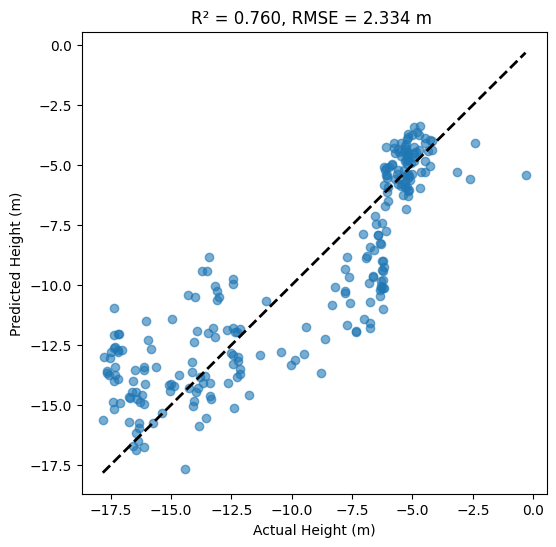

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6)
plt.plot([min(y_true), max(y_true)],
         [min(y_true), max(y_true)],
         'k--', lw=2)

plt.xlabel("Actual Height (m)")
plt.ylabel("Predicted Height (m)")
plt.title(f"R² = {r2:.3f}, RMSE = {rmse:.3f} m ")
plt.show()

In [ ]:
SDB_ST_Depth = (image.select('logratio')).multiply( slope ).add( intercept )

#SDB_ST = m0 + m1((ln1000B2)/(ln1000B3))
image = image.addBands(SDB_ST_Depth.rename('mySDB'))


In [ ]:
folium.Map.add_ee_layer = add_ee_layer
c = (AOI.centroid().getInfo())['coordinates']
map_matched = folium.Map(location=[c[1], c[0]], zoom_start=14)

depth_palette =  [
  '#30123b','#4145ab','#4675ed','#39a2fc','#1bcfd4',
  '#24eca6','#61fc6c','#a4fc3b','#d1e834','#f3c63a',
  '#fe9b2d','#f36315','#d93806','#a70d01'
]

map_matched.add_ee_layer(image,{'min':0, 'max':0.3, 'bands':['B4','B3','B2']},'RGB_L2A')
map_matched.add_ee_layer(image,{'min':-25, 'max':0, 'bands':['mySDB'], 'palette' : depth_palette},'h')

display(map_matched.add_child(folium.LayerControl()))

Thepchai Srinoi, Department of Survey Engineering Chulalongkorn University 2026